In [56]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

OUTPUT_DIR = Path("../outputs")

holdout_features = pd.read_parquet(
    OUTPUT_DIR / "holdout_features.parquet"
)

graph_result = pd.read_csv(
    OUTPUT_DIR / "anomaly_graph_score.csv"
)

print("holdout_features:", holdout_features.shape)
print("graph_result:", graph_result.shape)

holdout_features: (20000, 117)
graph_result: (20000, 11)


In [57]:
# Base table for clustering
cluster_base = holdout_features.copy()

# Candidate features for persona clustering
cluster_feature_candidates = [
    # Device
    "num_imeis_90d",
    "max_customers_per_imei",
    "shared_imei_flag",
    "high_shared_imei_flag",
    "rooted_session_ratio",
    "is_rooted",
    "emulator_session_ratio",
    "is_emulator",
    "low_tier_session_ratio",
    "low_tier_device_flag",
    "tac_grey_clone_flag",
    "tac_risk_score",

    # SIM
    "sim_swap_count_90d",
    "sim_swap_count_12m",
    "days_since_last_sim_swap",
    "recent_sim_change_flag",
    "iccid_count",
    "phone_number_age_days",
    "port_in_flag",

    # Behavior
    "distinct_ip_30d",
    "distinct_country_30d",
    "datacenter_ratio_30d",
    "vpn_proxy_ratio_30d",
    "non_residential_ratio_30d",
    "home_cell_ratio_30d",
    "night_session_ratio_30d",
    "geo_velocity_alerts_30d",
    "geo_velocity_flag_30d",
    "active_days_30d",
    "total_sessions_30d",
    "avg_sessions_per_day_30d",

    # Identity
    "kyc_level_ord",
    "has_face_score",
    "has_iddoc_score",
    "face_match_score",
    "id_doc_match_score",
]

# Keep only columns that exist
cluster_feature_cols = [
    col for col in cluster_feature_candidates
    if col in cluster_base.columns
]

missing_cluster_cols = [
    col for col in cluster_feature_candidates
    if col not in cluster_base.columns
]

print("Number of clustering features:", len(cluster_feature_cols))
print("Missing candidate features:", missing_cluster_cols)

Number of clustering features: 36
Missing candidate features: []


In [58]:
X_cluster_raw = cluster_base[cluster_feature_cols].copy()

print("X_cluster_raw shape:", X_cluster_raw.shape)

X_cluster_raw.head()

X_cluster_raw shape: (20000, 36)


,num_imeis_90d,max_customers_per_imei,shared_imei_flag,high_shared_imei_flag,rooted_session_ratio,is_rooted,emulator_session_ratio,is_emulator,low_tier_session_ratio,low_tier_device_flag,...,geo_velocity_alerts_30d,geo_velocity_flag_30d,active_days_30d,total_sessions_30d,avg_sessions_per_day_30d,kyc_level_ord,has_face_score,has_iddoc_score,face_match_score,id_doc_match_score
0,2,1,0,0,0.0,0,0.0,0,0.192308,1,...,0.0,0.0,7.0,7.0,1.000000,1,0,1,0.000,0.896
1,1,1,0,0,0.0,0,0.0,0,1.000000,1,...,0.0,0.0,8.0,9.0,1.125000,2,1,1,0.855,0.869
2,1,3,1,0,0.0,0,1.0,1,1.000000,1,...,0.0,0.0,5.0,5.0,1.000000,2,1,1,0.721,0.864
3,1,1,0,0,0.0,0,0.0,0,0.000000,0,...,0.0,0.0,6.0,7.0,1.166667,2,1,1,0.972,0.989
4,1,1,0,0,0.0,0,0.0,0,0.000000,0,...,0.0,0.0,6.0,7.0,1.166667,2,1,1,1.000,0.985


In [59]:
missing_rate = (
    X_cluster_raw
    .isna()
    .mean()
    .sort_values(ascending=False)
)

missing_rate[missing_rate > 0]

Series([], dtype: float64)

In [60]:
binary_cols = [
    "shared_imei_flag",
    "high_shared_imei_flag",
    "is_rooted",
    "is_emulator",
    "low_tier_device_flag",
    "tac_grey_clone_flag",
    "recent_sim_change_flag",
    "port_in_flag",
    "geo_velocity_flag_30d",
    "has_face_score",
    "has_iddoc_score",
]

count_cols = [
    "num_imeis_90d",
    "max_customers_per_imei",
    "sim_swap_count_90d",
    "sim_swap_count_12m",
    "iccid_count",
    "distinct_ip_30d",
    "distinct_country_30d",
    "geo_velocity_alerts_30d",
    "active_days_30d",
    "total_sessions_30d",
    "avg_sessions_per_day_30d",
]

day_cols = [
    "days_since_last_sim_swap",
    "phone_number_age_days",
]

continuous_cols = [
    "rooted_session_ratio",
    "emulator_session_ratio",
    "low_tier_session_ratio",
    "tac_risk_score",
    "datacenter_ratio_30d",
    "vpn_proxy_ratio_30d",
    "non_residential_ratio_30d",
    "home_cell_ratio_30d",
    "night_session_ratio_30d",
    "kyc_level_ord",
    "face_match_score",
    "id_doc_match_score",
]

binary_cols = [col for col in binary_cols if col in cluster_feature_cols]
count_cols = [col for col in count_cols if col in cluster_feature_cols]
day_cols = [col for col in day_cols if col in cluster_feature_cols]
continuous_cols = [col for col in continuous_cols if col in cluster_feature_cols]

print("binary:", len(binary_cols), binary_cols)
print("count:", len(count_cols), count_cols)
print("day:", len(day_cols), day_cols)
print("continuous:", len(continuous_cols), continuous_cols)

all_typed_cols = binary_cols + count_cols + day_cols + continuous_cols

missing_typed = sorted(set(cluster_feature_cols) - set(all_typed_cols))
missing_typed

binary: 11 ['shared_imei_flag', 'high_shared_imei_flag', 'is_rooted', 'is_emulator', 'low_tier_device_flag', 'tac_grey_clone_flag', 'recent_sim_change_flag', 'port_in_flag', 'geo_velocity_flag_30d', 'has_face_score', 'has_iddoc_score']
count: 11 ['num_imeis_90d', 'max_customers_per_imei', 'sim_swap_count_90d', 'sim_swap_count_12m', 'iccid_count', 'distinct_ip_30d', 'distinct_country_30d', 'geo_velocity_alerts_30d', 'active_days_30d', 'total_sessions_30d', 'avg_sessions_per_day_30d']
day: 2 ['days_since_last_sim_swap', 'phone_number_age_days']
continuous: 12 ['rooted_session_ratio', 'emulator_session_ratio', 'low_tier_session_ratio', 'tac_risk_score', 'datacenter_ratio_30d', 'vpn_proxy_ratio_30d', 'non_residential_ratio_30d', 'home_cell_ratio_30d', 'night_session_ratio_30d', 'kyc_level_ord', 'face_match_score', 'id_doc_match_score']


[]

In [61]:
X_cluster_processed_parts = []

if binary_cols:
    X_binary = X_cluster_raw[binary_cols].copy()
    X_binary = X_binary.fillna(0)
    X_cluster_processed_parts.append(X_binary)

if count_cols:
    X_count = X_cluster_raw[count_cols].copy()
    
    for col in count_cols:
        X_count[col] = np.log1p(X_count[col])
    
    count_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", RobustScaler()),
        ]
    )
    
    X_count_scaled = pd.DataFrame(
        count_pipeline.fit_transform(X_count),
        columns=count_cols,
        index=X_count.index,
    )
    
    X_cluster_processed_parts.append(X_count_scaled)

if day_cols:
    X_day = X_cluster_raw[day_cols].copy()
    
    for col in day_cols:
        upper = X_day[col].quantile(0.99)
        X_day[col] = X_day[col].clip(upper=upper)
        X_day[col] = np.log1p(X_day[col])
    
    day_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", RobustScaler()),
        ]
    )
    
    X_day_scaled = pd.DataFrame(
        day_pipeline.fit_transform(X_day),
        columns=day_cols,
        index=X_day.index,
    )
    
    X_cluster_processed_parts.append(X_day_scaled)

if continuous_cols:
    X_cont = X_cluster_raw[continuous_cols].copy()
    
    cont_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", RobustScaler()),
        ]
    )
    
    X_cont_scaled = pd.DataFrame(
        cont_pipeline.fit_transform(X_cont),
        columns=continuous_cols,
        index=X_cont.index,
    )
    
    X_cluster_processed_parts.append(X_cont_scaled)

X_cluster_df = pd.concat(X_cluster_processed_parts, axis=1)

X_cluster = X_cluster_df.values

X_cluster_df.shape

(20000, 36)

In [62]:
X_cluster_df.describe().T[
    ["mean", "std", "min", "25%", "50%", "75%", "max"]
].sort_values("max", ascending=False).head(20)

,mean,std,min,25%,50%,75%,max
avg_sessions_per_day_30d,0.502416,0.811425,-7.272541,0.000000,0.0,1.000000,9.613776
tac_risk_score,-0.076500,1.073827,-1.000000,-1.000000,0.0,0.000000,4.000000
night_session_ratio_30d,0.141785,0.745444,-0.500000,-0.500000,0.0,0.500000,3.500000
distinct_ip_30d,-0.063919,0.810185,-3.969362,-0.550340,0.0,0.449660,2.709511
iccid_count,0.315011,0.518393,0.000000,0.000000,0.0,1.000000,2.709511
active_days_30d,-0.236315,0.765977,-4.140202,-0.715893,0.0,0.284107,2.531010
sim_swap_count_12m,0.309745,0.503348,0.000000,0.000000,0.0,1.000000,2.321928
total_sessions_30d,-0.054869,0.653216,-3.310572,-0.572439,0.0,0.427561,2.296627
geo_velocity_alerts_30d,0.020644,0.124947,0.000000,0.000000,0.0,0.000000,1.609438
max_customers_per_imei,0.033594,0.153437,0.000000,0.000000,0.0,0.000000,1.504077


In [63]:
k_range = range(3, 9)

kmeans_results = []

for k in k_range:
    kmeans = KMeans(
        n_clusters=k,
        init="k-means++",
        random_state=42,
        n_init=20,
    )

    labels = kmeans.fit_predict(X_cluster)

    sil = silhouette_score(
        X_cluster,
        labels,
        sample_size=min(5000, X_cluster.shape[0]),
        random_state=42,
    )

    cluster_sizes = pd.Series(labels).value_counts(normalize=True)

    kmeans_results.append(
        {
            "k": k,
            "inertia": kmeans.inertia_,
            "silhouette": sil,
            "largest_cluster_pct": cluster_sizes.max(),
            "smallest_cluster_pct": cluster_sizes.min(),
        }
    )

kmeans_eval = pd.DataFrame(kmeans_results)

kmeans_eval

,k,inertia,silhouette,largest_cluster_pct,smallest_cluster_pct
0,3,136823.302618,0.292933,0.74195,0.10240
1,4,123324.433136,0.216233,0.49810,0.10235
2,5,114090.268201,0.211454,0.35550,0.10235
3,6,108219.168399,0.196862,0.24410,0.10230
4,7,104420.702551,0.179829,0.18665,0.10230
5,8,101602.853758,0.186640,0.18070,0.09555


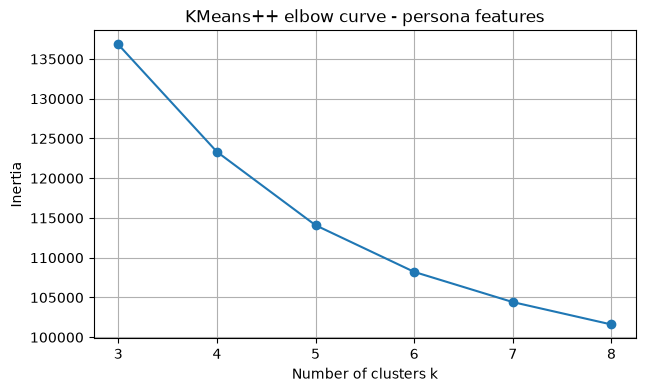

In [64]:
plt.figure(figsize=(7, 4))
plt.plot(kmeans_eval["k"], kmeans_eval["inertia"], marker="o")
plt.xlabel("Number of clusters k")
plt.ylabel("Inertia")
plt.title("KMeans++ elbow curve - persona features")
plt.grid(True)
plt.show()

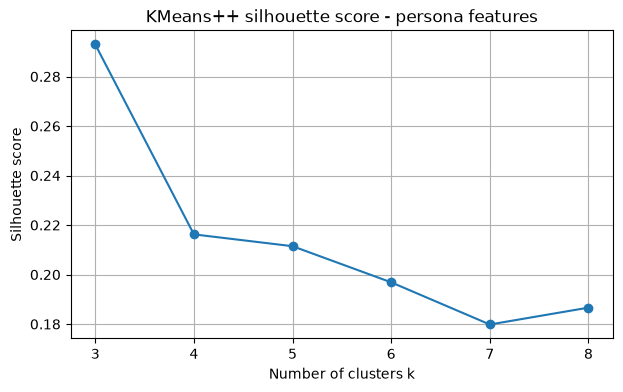

In [65]:
plt.figure(figsize=(7, 4))
plt.plot(kmeans_eval["k"], kmeans_eval["silhouette"], marker="o")
plt.xlabel("Number of clusters k")
plt.ylabel("Silhouette score")
plt.title("KMeans++ silhouette score - persona features")
plt.grid(True)
plt.show()

In [66]:
best_k = 4

kmeans_final = KMeans(
    n_clusters=best_k,
    init="k-means++",
    random_state=42,
    n_init=20,
)

cluster_labels = kmeans_final.fit_predict(X_cluster)

cluster_result = pd.DataFrame({
    "CustomerID": holdout_features["CustomerID"],
    "cluster_id": cluster_labels,
})

cluster_result.head()

,CustomerID,cluster_id
0,3000006,2
1,3000018,2
2,3000034,0
3,3000070,2
4,3000074,2


In [67]:
cluster_size = (
    cluster_result["cluster_id"]
    .value_counts()
    .sort_index()
    .rename("size")
    .to_frame()
)

cluster_size["size_pct"] = cluster_size["size"] / cluster_size["size"].sum()

cluster_size

,size,size_pct
cluster_id,,
0,3099,0.15495
1,2047,0.10235
2,9962,0.49810
3,4892,0.24460


In [68]:
# Merge graph/anomaly để profile, không dùng để fit

graph_profile_cols = [
    "CustomerID",
    "anomaly_score",
    "graph_adjusted_anomaly_score",
    "neighbor_count",
    "neighbor_anomaly_max",
    "neighbor_anomaly_mean",
]

graph_profile_cols = [
    col for col in graph_profile_cols
    if col in graph_result.columns
]

cluster_result = cluster_result.merge(
    graph_result[graph_profile_cols],
    on="CustomerID",
    how="left",
)

cluster_result.head()

,CustomerID,cluster_id,anomaly_score,graph_adjusted_anomaly_score,neighbor_count,neighbor_anomaly_max,neighbor_anomaly_mean
0,3000006,2,0.947015,0.916227,0,0.000000,0.000000
1,3000018,2,0.656145,0.648253,0,0.000000,0.000000
2,3000034,0,0.992115,0.996780,2,0.979775,0.852498
3,3000070,2,0.951015,0.919107,0,0.000000,0.000000
4,3000074,2,0.390540,0.389682,0,0.000000,0.000000


In [69]:
cluster_profile_df = holdout_features.merge(
    cluster_result,
    on="CustomerID",
    how="left",
)

cluster_profile_df.shape

(20000, 123)

In [70]:
cluster_summary = (
    cluster_profile_df
    .groupby("cluster_id")
    .agg(
        size=("CustomerID", "count"),
        anomaly_mean=("anomaly_score", "mean"),
        graph_anomaly_mean=("graph_adjusted_anomaly_score", "mean"),
        anomaly_p90=("graph_adjusted_anomaly_score", lambda x: x.quantile(0.90)),
        neighbor_count_mean=("neighbor_count", "mean"),
        neighbor_anomaly_max_mean=("neighbor_anomaly_max", "mean"),
    )
    .reset_index()
)

cluster_summary["size_pct"] = (
    cluster_summary["size"] / cluster_summary["size"].sum()
)

cluster_summary.sort_values("graph_anomaly_mean", ascending=False)

,cluster_id,size,anomaly_mean,graph_anomaly_mean,anomaly_p90,neighbor_count_mean,neighbor_anomaly_max_mean,size_pct
0,0,3099,0.652908,0.646870,0.899106,0.308487,0.083526,0.15495
1,1,2047,0.638416,0.633618,0.920745,0.503664,0.110182,0.10235
2,2,9962,0.450235,0.452508,0.842868,0.313993,0.083588,0.49810
3,3,4892,0.446660,0.447864,0.817169,0.217294,0.061868,0.24460


In [71]:
profile_cols = cluster_feature_cols.copy()

cluster_feature_profile = (
    cluster_profile_df
    .groupby("cluster_id")[profile_cols]
    .mean()
    .reset_index()
)

cluster_feature_profile

,cluster_id,num_imeis_90d,max_customers_per_imei,shared_imei_flag,high_shared_imei_flag,rooted_session_ratio,is_rooted,emulator_session_ratio,is_emulator,low_tier_session_ratio,...,geo_velocity_alerts_30d,geo_velocity_flag_30d,active_days_30d,total_sessions_30d,avg_sessions_per_day_30d,kyc_level_ord,has_face_score,has_iddoc_score,face_match_score,id_doc_match_score
0,0,1.109713,1.110358,0.051630,0.011617,0.026783,0.026783,0.946221,0.990319,0.976332,...,0.028396,0.027106,5.711520,6.330106,1.107890,1.599226,0.599226,1.000000,0.542082,0.925814
1,1,1.090865,1.205178,0.079629,0.025892,0.040059,0.040059,0.152729,0.161212,0.509609,...,0.031754,0.028823,5.576453,6.157792,1.100883,0.016610,0.003908,0.012702,0.003493,0.004660
2,2,1.075888,1.087332,0.050191,0.004015,0.022184,0.022184,0.000000,0.000000,0.434473,...,0.043365,0.036840,6.720638,7.534732,1.129763,1.601988,0.601988,1.000000,0.544878,0.924908
3,3,1.079109,1.079109,0.045993,0.004088,0.017171,0.017171,0.001583,0.001840,0.441118,...,0.008994,0.008790,3.450123,3.627146,1.051842,1.603230,0.603230,1.000000,0.546043,0.924315


In [72]:
global_mean = cluster_profile_df[profile_cols].mean()

cluster_lift = (
    cluster_profile_df
    .groupby("cluster_id")[profile_cols]
    .mean()
    .div(global_mean.replace(0, np.nan))
)

cluster_lift = cluster_lift.replace([np.inf, -np.inf], np.nan)

cluster_lift

,num_imeis_90d,max_customers_per_imei,shared_imei_flag,high_shared_imei_flag,rooted_session_ratio,is_rooted,emulator_session_ratio,is_emulator,low_tier_session_ratio,low_tier_device_flag,...,geo_velocity_alerts_30d,geo_velocity_flag_30d,active_days_30d,total_sessions_30d,avg_sessions_per_day_30d,kyc_level_ord,has_face_score,has_iddoc_score,face_match_score,id_doc_match_score
cluster_id,,,,,,,,,,,,,,,,,,,,,
0,1.024240,1.008546,0.985297,1.559282,1.139695,1.139695,5.818036,5.811734,1.849991,1.812415,...,0.902902,0.980308,1.011390,1.012598,1.003198,1.110882,1.108343,1.112409,1.107830,1.114478
1,1.006844,1.094671,1.519632,3.475376,1.704622,1.704622,0.939083,0.946077,0.965627,0.963316,...,1.009659,1.042411,0.987472,0.985034,0.996853,0.011538,0.007229,0.014129,0.007138,0.005610
2,0.993021,0.987631,0.957838,0.538961,0.944013,0.944013,0.000000,0.000000,0.823256,0.833434,...,1.378849,1.332369,1.190083,1.205297,1.023004,1.112800,1.113451,1.112409,1.113543,1.113387
3,0.995993,0.980161,0.877738,0.548766,0.730676,0.730676,0.009731,0.010797,0.835847,0.839891,...,0.285987,0.317897,0.610944,0.580218,0.952446,1.113663,1.115749,1.112409,1.115925,1.112672


In [73]:
for cid in sorted(cluster_lift.index):
    print(f"\nCluster {cid}")
    display(
        cluster_lift
        .loc[cid]
        .sort_values(ascending=False)
        .head(12)
        .to_frame("lift")
    )


Cluster 0


,lift
emulator_session_ratio,5.818036
is_emulator,5.811734
tac_grey_clone_flag,5.674041
tac_risk_score,3.269127
low_tier_session_ratio,1.849991
low_tier_device_flag,1.812415
high_shared_imei_flag,1.559282
phone_number_age_days,1.194681
recent_sim_change_flag,1.157724
is_rooted,1.139695



Cluster 1


,lift
high_shared_imei_flag,3.475376
rooted_session_ratio,1.704622
is_rooted,1.704622
vpn_proxy_ratio_30d,1.674667
non_residential_ratio_30d,1.577557
shared_imei_flag,1.519632
datacenter_ratio_30d,1.511381
max_customers_per_imei,1.094671
geo_velocity_flag_30d,1.042411
tac_grey_clone_flag,1.038695



Cluster 2


,lift
geo_velocity_alerts_30d,1.378849
geo_velocity_flag_30d,1.332369
total_sessions_30d,1.205297
active_days_30d,1.190083
distinct_ip_30d,1.175212
face_match_score,1.113543
has_face_score,1.113451
id_doc_match_score,1.113387
kyc_level_ord,1.112800
has_iddoc_score,1.112409



Cluster 3


,lift
face_match_score,1.115925
has_face_score,1.115749
kyc_level_ord,1.113663
id_doc_match_score,1.112672
has_iddoc_score,1.112409
recent_sim_change_flag,1.037681
sim_swap_count_90d,1.024158
sim_swap_count_12m,1.022077
iccid_count,1.005453
days_since_last_sim_swap,0.999551


## Phân cụm khách hàng và xây dựng persona

### Mục tiêu

Mục tiêu của bước này là phân nhóm khách hàng trong tập holdout thành các **persona hành vi** có thể diễn giải được về mặt nghiệp vụ.

Mô hình **KMeans++** được áp dụng trên một tập feature đã chọn lọc theo 4 nhóm tín hiệu chính của Device Trust Score:

* **Tín hiệu thiết bị**
* **Tín hiệu ổn định SIM**
* **Tín hiệu nhất quán hành vi**
* **Tín hiệu độ tin cậy danh tính**

Các biến như `anomaly_score`, `graph_adjusted_anomaly_score` và các feature graph **không được dùng để huấn luyện mô hình clustering**. Những biến này chỉ được dùng sau khi phân cụm để đánh giá mức độ rủi ro của từng cụm.

---

### Thiết lập clustering

KMeans++ được chọn vì đây là phương pháp đơn giản, dễ diễn giải và phù hợp để tạo các nhóm khách hàng có ý nghĩa nghiệp vụ.

Ma trận đầu vào cho clustering chỉ sử dụng các feature numeric đã được chọn lọc, liên quan đến thiết bị, SIM, hành vi và danh tính. Các biến định danh, biến categorical gốc, anomaly score, graph score và các output score khác được loại khỏi đầu vào clustering.

Quy trình tiền xử lý feature gồm:

* Các biến binary flag được giữ ở dạng `0/1`.
* Các biến dạng count được biến đổi bằng `log1p`.
* Các biến dạng ngày/tuổi có đuôi dài được cap ở percentile 99% rồi biến đổi bằng `log1p`.
* Các biến liên tục được impute bằng median và scale bằng `RobustScaler`.

Số cụm cuối cùng được chọn là `k = 4`.

Mặc dù silhouette score ở mức trung bình, `k = 4` được chọn vì tạo ra các cụm cân bằng và dễ diễn giải hơn về mặt nghiệp vụ. Trong bài toán này, mục tiêu của clustering không phải là tìm các cụm tách biệt hoàn toàn về mặt hình học, mà là hỗ trợ phân nhóm khách hàng theo các persona rủi ro có thể đọc hiểu được.

---

## Tóm tắt các persona

| Cluster |                   Quy mô | Mức rủi ro      | Tên persona                                                | Diễn giải chính                                                                                          |
| ------: | -----------------------: | --------------- | ---------------------------------------------------------- | -------------------------------------------------------------------------------------------------------- |
|       0 | 3,099 khách hàng - 15.5% | Cao             | **Nghi vấn device farm / thiết bị giả lập hoặc low-tier**  | Nhóm có tín hiệu emulator, thiết bị low-tier, TAC risk và grey/clone device cao.                         |
|       1 | 2,047 khách hàng - 10.2% | Cao             | **Danh tính yếu / nghi vấn mạng lưới dùng chung thiết bị** | Nhóm có tín hiệu định danh yếu, đồng thời có shared-device và network-link cao hơn trung bình.           |
|       2 | 9,962 khách hàng - 49.8% | Trung bình-thấp | **Người dùng đã xác minh, hoạt động cao**                  | Nhóm người dùng đã xác minh đầy đủ, có cường độ hoạt động cao hơn nhưng không có tín hiệu emulator mạnh. |
|       3 | 4,892 khách hàng - 24.5% | Thấp            | **Người dùng ổn định, thiết bị cá nhân đã xác minh**       | Nhóm ổn định nhất, có KYC tốt, ít tín hiệu graph risk và anomaly thấp.                                   |

---

## Cluster 0 - Nghi vấn device farm / thiết bị giả lập hoặc low-tier

Cluster 0 chiếm khoảng **15.5%** tập holdout và có mức `graph_adjusted_anomaly_score` trung bình cao nhất trong bốn cụm.

Cụm này nổi bật bởi các tín hiệu rủi ro về thiết bị:

* `emulator_session_ratio` cao.
* Tỷ lệ `is_emulator` cao.
* `tac_grey_clone_flag` cao.
* `tac_risk_score` cao.
* Tỷ lệ sử dụng thiết bị low-tier cao.
* Có tín hiệu shared IMEI cao hơn trung bình.

Những đặc điểm này cho thấy cụm này có xu hướng liên quan đến các thiết bị rủi ro như thiết bị giả lập, thiết bị low-tier, hoặc các mẫu thiết bị/TAC có khả năng grey/clone.

**Tên persona:**
**Nghi vấn device farm / thiết bị giả lập hoặc low-tier**

**Diễn giải nghiệp vụ:**
Đây là cụm phù hợp nhất với persona dạng device farm. Cụm này nên được xem là nhóm có rủi ro cao về device integrity, đặc biệt khi đi kèm với risky IP, liên kết graph hoặc các bất thường hành vi khác.

---

## Cluster 1 - Danh tính yếu / nghi vấn mạng lưới dùng chung thiết bị

Cluster 1 chiếm khoảng **10.2%** tập holdout và cũng có mức rủi ro trung bình cao.

Cụm này nổi bật bởi các tín hiệu định danh yếu:

* `kyc_level_ord` rất thấp.
* `has_face_score` gần bằng 0.
* `has_iddoc_score` gần bằng 0.
* Điểm khớp khuôn mặt và giấy tờ định danh rất thấp.
* Tín hiệu shared IMEI cao hơn trung bình.
* Tín hiệu high-shared-IMEI cao hơn đáng kể.
* Tín hiệu rooted device cao hơn trung bình.
* `neighbor_count_mean` cao nhất trong các cụm.

Điều này cho thấy đây là nhóm có độ tin cậy danh tính thấp, đồng thời có nhiều dấu hiệu liên quan đến dùng chung thiết bị hoặc liên kết mạng lưới.

**Tên persona:**
**Danh tính yếu / nghi vấn mạng lưới dùng chung thiết bị**

**Diễn giải nghiệp vụ:**
Cụm này có thể đại diện cho các tài khoản có chất lượng định danh thấp, mule-like accounts hoặc các mạng lưới dùng chung thiết bị. Shared IMEI không được coi là dấu hiệu gian lận tuyệt đối, vì trong thực tế có thể có các trường hợp hợp lệ như người thân dùng chung máy hoặc chuyển nhượng thiết bị. Tuy nhiên, khi shared-device pattern đi kèm với KYC yếu, rooted device và graph neighbor risk cao, tín hiệu này trở nên đáng chú ý hơn.

---

## Cluster 2 - Người dùng đã xác minh, hoạt động cao

Cluster 2 là cụm lớn nhất, chiếm khoảng **49.8%** tập holdout.

Cụm này có mức rủi ro thấp hơn Cluster 0 và Cluster 1, nhưng có cường độ hoạt động cao hơn:

* KYC nhìn chung đầy đủ.
* Gần như không có tín hiệu emulator.
* Số ngày hoạt động trong 30 ngày cao hơn.
* Tổng số session trong 30 ngày cao hơn.
* `graph_adjusted_anomaly_score` ở mức trung bình-thấp.

**Tên persona:**
**Người dùng đã xác minh, hoạt động cao**

**Diễn giải nghiệp vụ:**
Cụm này nhiều khả năng đại diện cho nhóm người dùng thật, đã xác minh đầy đủ, nhưng có tần suất hoạt động cao. Một số tín hiệu hành vi biến động có thể đến từ việc sử dụng dịch vụ thường xuyên, di chuyển nhiều hoặc có nhiều phiên truy cập. Không nên coi nhóm này là gian lận chỉ vì activity volume cao.

---

## Cluster 3 - Người dùng ổn định, thiết bị cá nhân đã xác minh

Cluster 3 chiếm khoảng **24.5%** tập holdout và có mức `graph_adjusted_anomaly_score` trung bình thấp nhất.

Cụm này thể hiện các đặc điểm ổn định và ít rủi ro:

* KYC nhìn chung đầy đủ.
* Gần như không có tín hiệu emulator.
* Tín hiệu rooted device thấp.
* Geo-velocity alerts thấp.
* Cường độ hoạt động thấp hơn nhóm high-activity.
* Neighbor count và graph risk thấp nhất trong các cụm.

**Tên persona:**
**Người dùng ổn định, thiết bị cá nhân đã xác minh**

**Diễn giải nghiệp vụ:**
Đây là nhóm khách hàng đáng tin cậy nhất trong kết quả clustering. Khách hàng trong cụm này có xu hướng sử dụng thiết bị cá nhân ổn định, có bằng chứng định danh tốt và ít thể hiện các tín hiệu rủi ro về mạng, thiết bị hoặc hành vi di chuyển.

---

## Kết luận chính

Kết quả clustering chia khách hàng thành 4 persona có thể diễn giải được:

1. **Nhóm rủi ro thiết bị**: có dấu hiệu emulator, low-tier device và grey/clone device.
2. **Nhóm rủi ro danh tính/mạng lưới**: KYC yếu và có dấu hiệu dùng chung thiết bị hoặc liên kết graph.
3. **Nhóm người dùng thật hoạt động cao**: đã xác minh đầy đủ, có nhiều hoạt động và session hơn.
4. **Nhóm người dùng ổn định, tin cậy cao**: đã xác minh, thiết bị ổn định và ít tín hiệu bất thường.

Việc phân cụm này giúp tách các pattern rủi ro thật sự về thiết bị và danh tính khỏi các hành vi hợp lệ như người dùng hoạt động nhiều hoặc di chuyển thường xuyên.